### Imports & display options: Load pandas/numpy/plotting, set wide display. Bring in StandardScaler, KMeans, silhouette, and TSNE. Define RS and silence warnings.

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.patches import Rectangle

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to perform t-SNE
from sklearn.manifold import TSNE

# to define a common seed value to be used throughout
RS=0

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Chips dataset
chips_path = r"Chips.csv"
df_chips = pd.read_csv(chips_path).drop(columns=['Unnamed: 0'])

# Reverse spectral columns
df_chips = pd.concat(
    [
        df_chips.iloc[:, :2],
        df_chips.iloc[:, 2:].iloc[:, ::-1]
    ],
    axis=1
)

display(df_chips.head())

Oil Type Chips Type  500.9077  501.8718  502.8362  503.8003  504.7646  \
0    GNO C    GNO C 1  0.348234  0.236003  0.209548  0.259935  0.342311   
1    GNO C    GNO C 1  0.578053  0.812538  0.758810  0.585610  0.359928   
2    GNO C    GNO C 1 -0.905678  0.159808  0.698343  0.792267  0.597913   
3    GNO C    GNO C 1 -0.523754 -0.562153 -0.553895 -0.579130 -0.649199   
4    GNO C    GNO C 1  0.741291  0.749648  0.541832  0.263461 -0.060196   

   505.7288  506.6931  507.6572  508.6216  509.5857    510.55  511.5142  \
0  0.400750  0.265417 -0.057315 -0.411431 -0.674833 -0.854471 -0.979350   
1  0.130024  0.097454  0.242493  0.488946  0.713690  0.807781  0.824831   
2  0.217841 -0.055928 -0.205510 -0.217652 -0.128886  0.078317  0.435144   
3 -0.752685 -0.946942 -1.207011 -1.440173 -1.572829 -1.619723 -1.669355   
4 -0.403371 -0.680328 -0.867349 -0.974554 -1.016241 -0.975795 -0.815243   

   512.4785  513.4426   514.407  515.3711  516.3354  517.2996  518.2639  \
0 -0.949766 -0.717963 -0.334556 -0.061177 -0.117032 -0.526259 -1.076743   
1  0.833879  0.775224  0.605560  0.438121  0.442291  0.666798  0.998243   
2  0.816418  1.017497  0.948822  0.803896  0.778733  0.914833  1.103996   
3 -1.742555 -1.722702 -1.558242 -1.332234 -1.158859 -1.045759 -0.924139   
4 -0.537145 -0.223300  0.054389  0.314927  0.579800  0.809266  0.975225   

    519.228  520.1924  521.1565  522.1208   523.085  524.0493  525.0134  \
0 -1.439732 -1.418992 -1.083193 -0.603585 -0.137366  0.325810  0.748512   
1  1.307873  1.559327  1.769207  1.891850  1.747057  1.417143  1.069955   
2  1.198472  1.147995  1.070681  1.095661  1.246867  1.318819  1.149652   
3 -0.794730 -0.736788 -0.849267 -1.105689 -1.344639 -1.449761 -1.354985   
4  1.149291  1.386776  1.615790  1.727173  1.596729  1.367316  1.160687   

   525.9778  526.9419  527.9063  528.8704  529.8347  530.7988  531.7632  \
0  1.036318  1.162766  1.185935  1.153004  1.011759  0.701665  0.278802   
1  0.839287  0.802381  0.918607  1.064316  1.047834  0.723812  0.273348   
2  0.923384  0.926457  1.228504  1.657763  1.996756  2.161273  2.171097   
3 -1.151387 -1.004516 -0.988687 -1.056374 -1.054220 -0.888664 -0.701873   
4  1.001211  0.908562  0.935664  1.131241  1.396584  1.473812  1.185226   

   532.7273  533.6917  534.6558  535.6201  536.5842  537.5486  538.5127  \
0 -0.195700 -0.538836 -0.601601 -0.328225  0.105446  0.505060  0.711020   
1 -0.091889 -0.204164 -0.192360 -0.232926 -0.205038 -0.021153  0.241734   
2  1.963761  1.358480  0.528743 -0.087439 -0.321034 -0.250712 -0.013094   
3 -0.599561 -0.489240 -0.225961  0.178468  0.518511  0.706909  0.786214   
4  0.518830 -0.126223 -0.377796 -0.061984  0.434430  0.724611  0.677231   

   539.4771  540.4412  541.4055  542.3696   543.334  544.2981  545.2625  \
0  0.619200  0.234495 -0.279409 -0.747359 -1.030446 -1.081784 -0.961040   
1  0.438433  0.562598  0.713176  0.745639  0.413238 -0.144478 -0.650409   
2  0.283488  0.567869  0.734616  0.832254  1.042722  1.154902  0.862800   
3  0.833385  0.765520  0.419210 -0.099899 -0.571725 -0.785530 -0.709534   
4  0.367404 -0.100709 -0.626267 -1.030689 -1.020067 -0.543392  0.192758   

   546.2266  547.1909   548.155  549.1194  550.0835  551.0479   552.012  \
0 -0.823207 -0.735045 -0.676820 -0.621787 -0.583907 -0.523907 -0.380251   
1 -0.842273 -0.730485 -0.405078  0.054332  0.481103  0.658161  0.466980   
2  0.168591 -0.569286 -0.915661 -0.814480 -0.450342  0.035516  0.575150   
3 -0.481561 -0.184798  0.165330  0.466398  0.584138  0.495787  0.291673   
4  0.740732  0.984821  1.041505  1.033837  1.090048  1.235909  1.432143   

   552.9763  553.9404  554.9048  555.8689  556.8333  557.7974  558.7617  \
0 -0.127619  0.190713  0.506468  0.797993  0.929447  0.822119  0.479342   
1  0.012389 -0.347054 -0.478526 -0.475755 -0.432053 -0.394156 -0.312574   
2  1.048994  1.064822  0.603557  0.134078  0.018635  0.280646  0.656744   
3  0.065353 -0.072230 -0.048088  0.176654  0.355077  0.292582 -0.064078   
4  1.583418  1.5083

In [3]:
# Spectral data starts from column 2
spectra = df_chips.iloc[:, 2:]

# Most negative value in the entire spectral dataset
min_value = spectra.min().min()

# Find row and column containing the minimum value
row_idx, col_idx = (spectra == min_value).stack().idxmax()

print("Most negative value:", min_value)
print("Most negative value:", min_value)
print("Row index:", row_idx)
print("Wavenumber:", col_idx)

print("Shift skipped (data is already Z-score normalized; negative values are physically meaningful)")
print("Minimum stays:", df_chips.iloc[:, 2:].min().min())

Most negative value: -4.304114100701882
Most negative value: -4.304114100701882
Row index: 643
Wavenumber: 500.9077
Shift skipped (data is already Z-score normalized; negative values are physically meaningful)
Minimum stays: -4.304114100701882


In [4]:
#Define features (X) and Target (y)
X = df_chips.drop(columns=['Oil Type','Chips Type'])
y= df_chips['Oil Type']
X = X.astype(float)
#X,y

### Build X (features) and keep y (labels) for later validation after clustering algo. 

In [5]:
df = X

### Scaling

### Scaling is compulsory for clustering

In [6]:
# scaling the data before clustering
scaler = StandardScaler()
subset = df.copy()
subset_scaled = scaler.fit_transform(subset)

In [7]:
# creating a dataframe of the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

### t‑SNE to 2D (for visualization only): Reduce to 2D with t‑SNE (random_state=RS), create `Features 1 and 2` DataFrame, quick preview.

In [8]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, n_jobs=-2, random_state=RS, perplexity = 30.0)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions

In [9]:
tsne_2d_data.head()

,Feature 1,Feature 2
0,14.163313,2.953029
1,8.373345,2.663374
2,-0.330608,4.649858
3,-12.652950,6.369026
4,-12.832488,2.342283


In [10]:
palette = {
    "SO C": "tab:blue",
    "PO C": "tab:orange",
    "GNO C": "tab:green",
    "SOYO C": "tab:red",
    "VO C": "tab:purple"
}

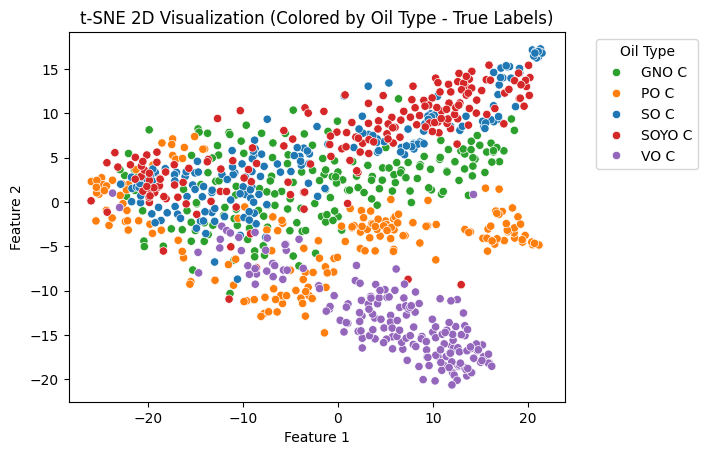

In [11]:
# #Add true labels 
tsne_2d_data = tsne_2d_data.copy()
tsne_2d_data["Oil Type"] = y.reset_index(drop = True)

#Plot with colors = oil type
sns.scatterplot(
    data = tsne_2d_data,
    x = "Feature 1",
    y = "Feature 2",
    hue = "Oil Type",
    palette=palette
    #palette = "tab10"
)
plt.legend(title = "Oil Type", bbox_to_anchor = (1.05,1))
plt.title("t-SNE 2D Visualization (Colored by Oil Type - True Labels)")
plt.savefig(r"Images\K-Means Clusters\tsne_plot_default_chips.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()

In [12]:
# Let us check the default perplexity. Perplexity is the number of neighbors influencing each point
print(TSNE().get_params()["perplexity"])

30.0


### t‑SNE sensitivity to perplexity: Multiple 2D views at different perplexities to check stability of local neighborhoods.

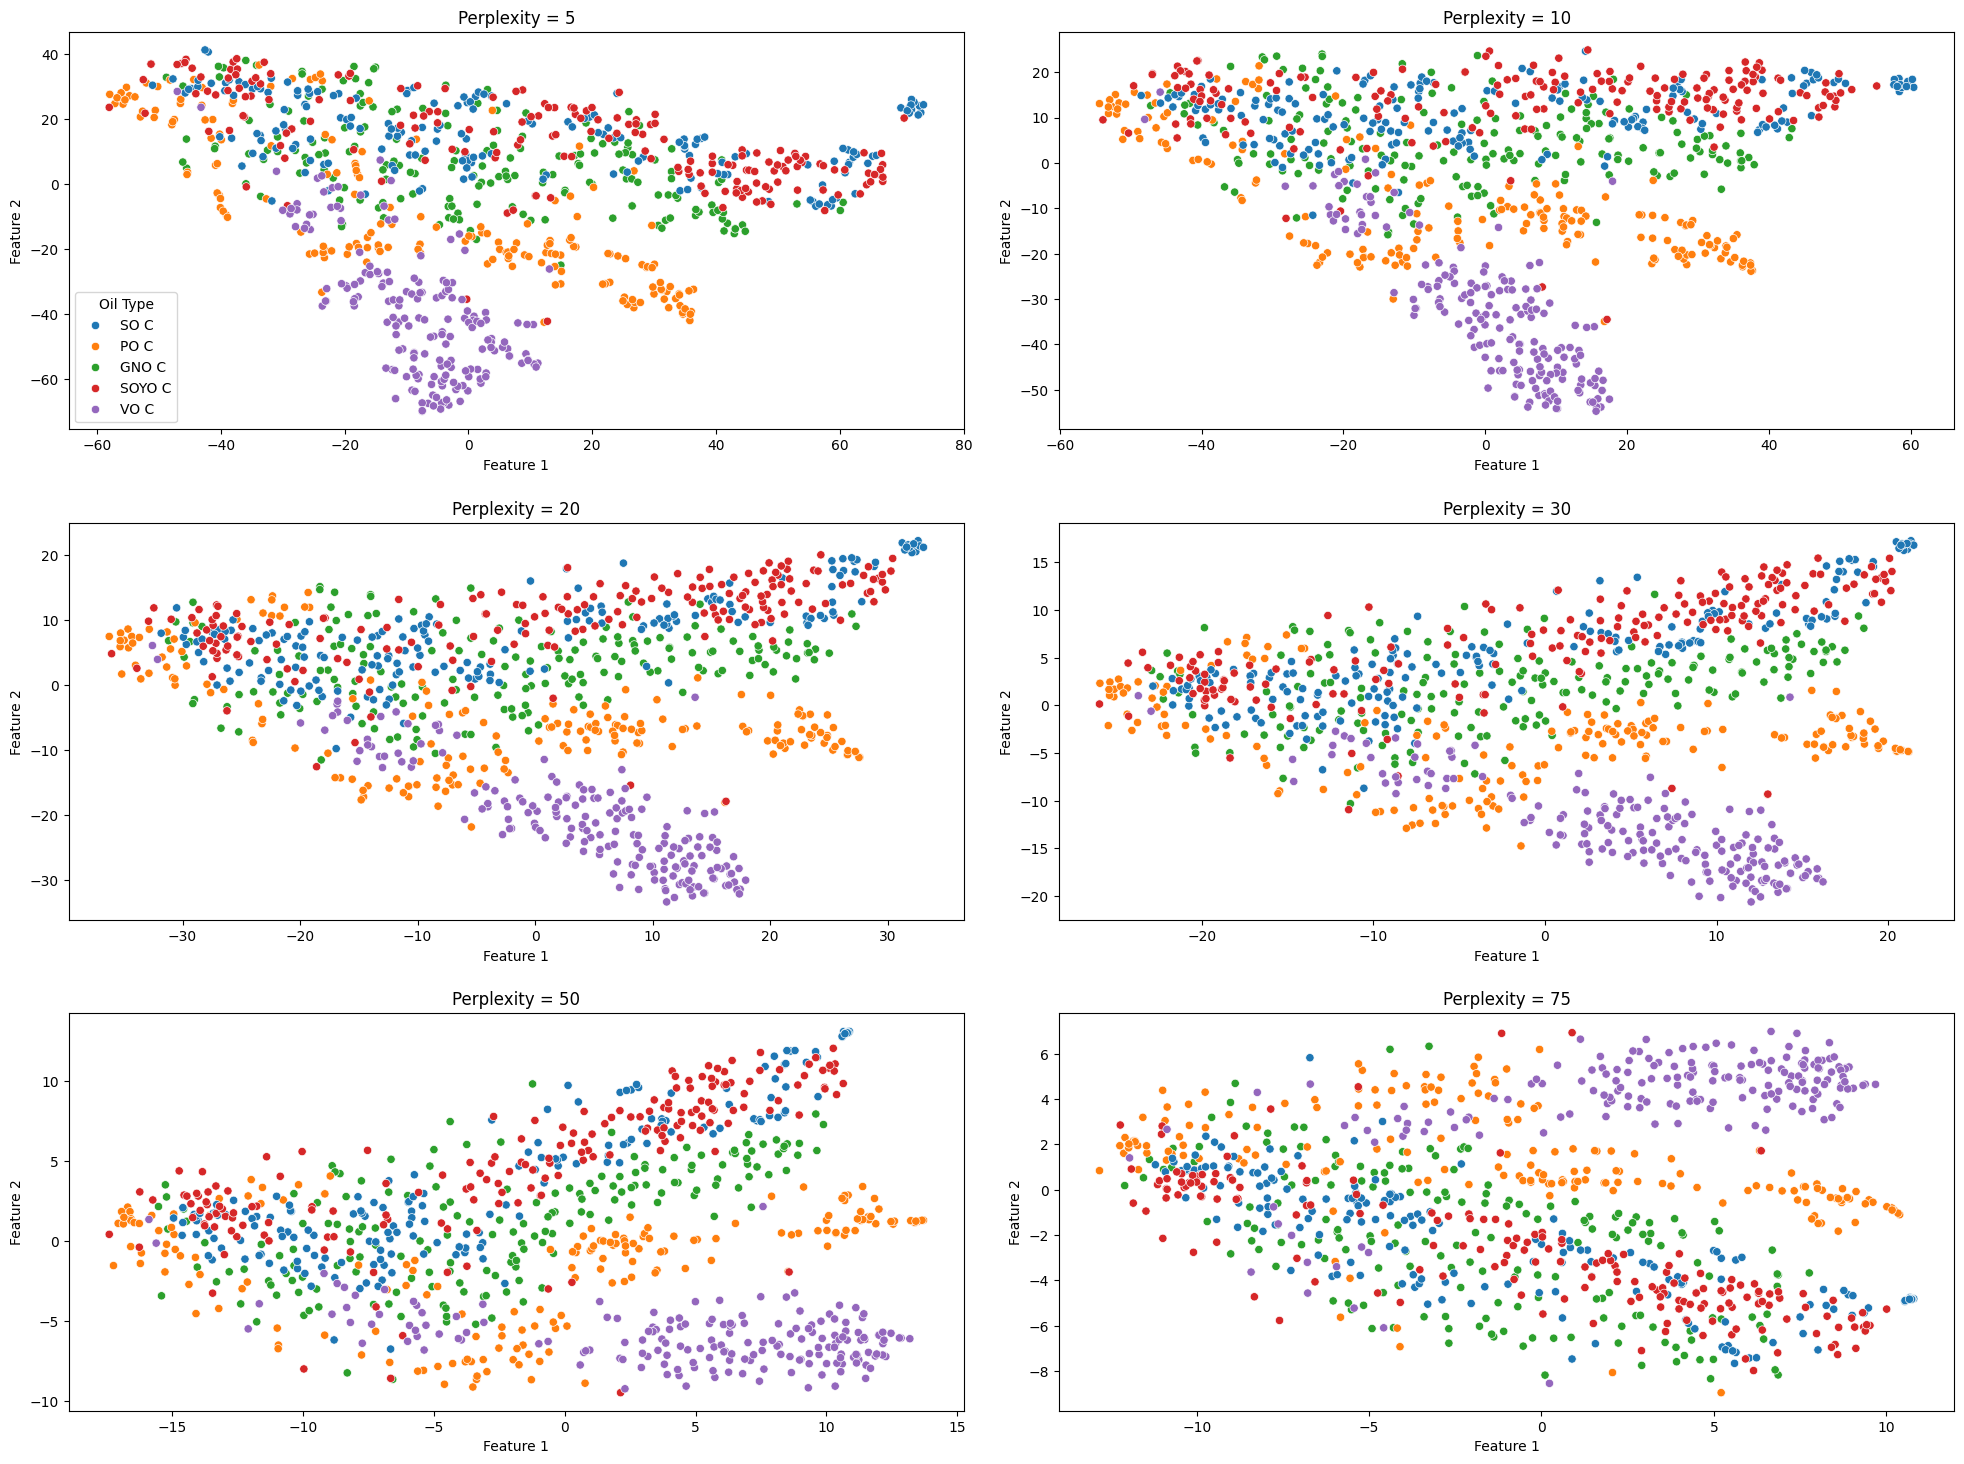

In [13]:
hue_order = ["SO C", "PO C", "GNO C", "SOYO C", "VO C"]

# Define the list of perplexity values to iterate over
perplexities = [5, 10, 20, 30, 50, 75]

plt.figure(figsize=(20, 15))

for i in range(len(perplexities)):

    tsne = TSNE(
        n_components=2,
        perplexity=perplexities[i],
        n_jobs=-2,
        random_state=RS
    )

    X_red = tsne.fit_transform(subset_scaled_df)

    red_data_df = pd.DataFrame(
        data=X_red,
        columns=["Feature 1", "Feature 2"]
    )

    red_data_df["Oil Type"] = y.reset_index(drop=True)

    plt.subplot(3, 2, i + 1)

    sns.scatterplot(
        data=red_data_df,
        x="Feature 1",
        y="Feature 2",
        hue="Oil Type",
        hue_order=hue_order,
        palette=palette
    )

    plt.title(f"Perplexity = {perplexities[i]}")

    # Optional: show legend only on first plot
    if i != 0:
        plt.legend([], [], frameon=False)

plt.tight_layout(pad=2)
plt.savefig(r"Images\K-Means Clusters\tsne_perplexity_grid_chips.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()

###  t‑SNE to 2D & 3D (fixed perplexity=50): Produce 2D and 3D embeddings; preview few rows.

In [14]:
# Initiating the t-SNE object
# n_components=2 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one processor core for parallel computation, which speeds up the process
tsne = TSNE(n_components=2, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the t-SNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_2d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2"])) # This DataFrame will have two columns corresponding to the two reduced dimensions
tsne_2d_data.head()

,Feature 1,Feature 2
0,7.801625,4.142898
1,3.700648,3.001789
2,-1.575903,1.082079
3,-7.774474,3.758315
4,-9.038331,1.097458


In [15]:
# Add oil labels to t-SNE data
tsne_2d_data ["Oil Type"] = y.reset_index(drop = True)
# Save to CSV
tsne_2d_data.to_csv(r"Images\K-Means Clusters\tsne_2d_data_with_chips.csv", index = False)

In [16]:
# Read CSV file
df_check = pd.read_csv(r"Images\K-Means Clusters\tsne_2d_data_with_chips.csv")
print(df_check.columns)
print(df_check.shape)
print(df_check.nunique())
print(df_check.head())

Index(['Feature 1', 'Feature 2', 'Oil Type'], dtype='object')
(900, 3)
Feature 1    900
Feature 2    900
Oil Type       5
dtype: int64
   Feature 1  Feature 2 Oil Type
0   7.801625   4.142898    GNO C
1   3.700648   3.001789    GNO C
2  -1.575903   1.082079    GNO C
3  -7.774474   3.758315    GNO C
4  -9.038331   1.097458    GNO C


In [17]:
# Group oil type and obtain min/max ranges:
range_df = tsne_2d_data.groupby("Oil Type").agg({"Feature 1": ["min", "max"],"Feature 2": ["min", "max"]})
print(range_df)

          Feature 1            Feature 2           
                min        max       min        max
Oil Type                                           
GNO C    -15.531159   9.891005 -8.633542   9.808693
PO C     -17.251713  13.715719 -9.111832   4.060572
SO C     -14.953297  10.883938 -6.742475  13.086393
SOYO C   -17.413935  10.648054 -9.465054  12.031985
VO C     -15.895817  13.193136 -9.223381   2.153098


In [18]:
# Initiating the TSNE object and setting output dimension to 3
# n_components=3 specifies the number of dimensions to reduce the data to
# n_jobs=-2 specifies to use all but one core for parallel computation, which speeds up the process
tsne = TSNE(n_components=3, perplexity=50, n_jobs=-2, random_state=RS)

# Performing dimensionality reduction on the scaled data
# fit_transform() fits the TSNE model to the data and transforms it into the specified number of dimensions
tsne_reduced_data = tsne.fit_transform(subset_scaled_df)

# Creating a DataFrame from the reduced data
tsne_3d_data = pd.DataFrame(tsne_reduced_data, columns=(["Feature 1","Feature 2","Feature 3"])) # This DataFrame will have three columns corresponding to the three reduced dimensions

In [19]:
tsne_3d_data.head()

,Feature 1,Feature 2,Feature 3
0,4.925897,-0.848985,-1.393085
1,3.447292,0.288509,-0.979495
2,2.199241,-1.877017,-0.632959
3,-4.078532,2.359799,-1.720945
4,-6.408432,-0.145930,4.377533


In [20]:
# Add oil labels to the 3D t-SNE dataframe
tsne_3d_data["Oil Type"] = y.reset_index(drop=True)

# Optional: move Oil_Type to the first column
cols = ["Oil Type", "Feature 1", "Feature 2", "Feature 3"]
tsne_3d_data = tsne_3d_data[cols]

# Check the result
display(tsne_3d_data.head())

# Save as CSV
tsne_3d_data.to_csv(r"Images\K-Means Clusters\tsne_3d_with_chips_labels.csv", index=False)

print("CSV saved as: tsne_3d_with_chips_labels.csv")

,Oil Type,Feature 1,Feature 2,Feature 3
0,GNO C,4.925897,-0.848985,-1.393085
1,GNO C,3.447292,0.288509,-0.979495
2,GNO C,2.199241,-1.877017,-0.632959
3,GNO C,-4.078532,2.359799,-1.720945
4,GNO C,-6.408432,-0.145930,4.377533


CSV saved as: tsne_3d_with_chips_labels.csv


In [21]:
# Read CSV file
df_check = pd.read_csv(r"Images\K-Means Clusters\tsne_3d_with_chips_labels.csv")
print(df_check.columns)
print(df_check.shape)
print(df_check.nunique())
print(df_check.head())

Index(['Oil Type', 'Feature 1', 'Feature 2', 'Feature 3'], dtype='object')
(900, 4)
Oil Type       5
Feature 1    900
Feature 2    900
Feature 3    900
dtype: int64
  Oil Type  Feature 1  Feature 2  Feature 3
0    GNO C   4.925897  -0.848985  -1.393085
1    GNO C   3.447292   0.288509  -0.979495
2    GNO C   2.199241  -1.877017  -0.632959
3    GNO C  -4.078532   2.359799  -1.720945
4    GNO C  -6.408431  -0.145930   4.377533


In [22]:
# Group oil type and obtain min/max ranges:
range_df = tsne_3d_data.groupby("Oil Type").agg({"Feature 1": ["min", "max"],"Feature 2": ["min", "max"],"Feature 3": ["min", "max"]})
print(range_df)

          Feature 1           Feature 2           Feature 3          
                min       max       min       max       min       max
Oil Type                                                             
GNO C     -9.813405  6.542937 -5.180116  5.152173 -6.098701  5.175255
PO C     -10.169420  9.376295 -4.534147  4.737011 -2.590941  5.968704
SO C      -9.371636  9.721337 -3.903377  2.659223 -6.300182  4.532284
SOYO C   -10.146254  8.709848 -4.818784  4.017149 -7.042061  7.427385
VO C     -10.271208  7.935470 -4.771635  3.760026  0.652028  6.943715


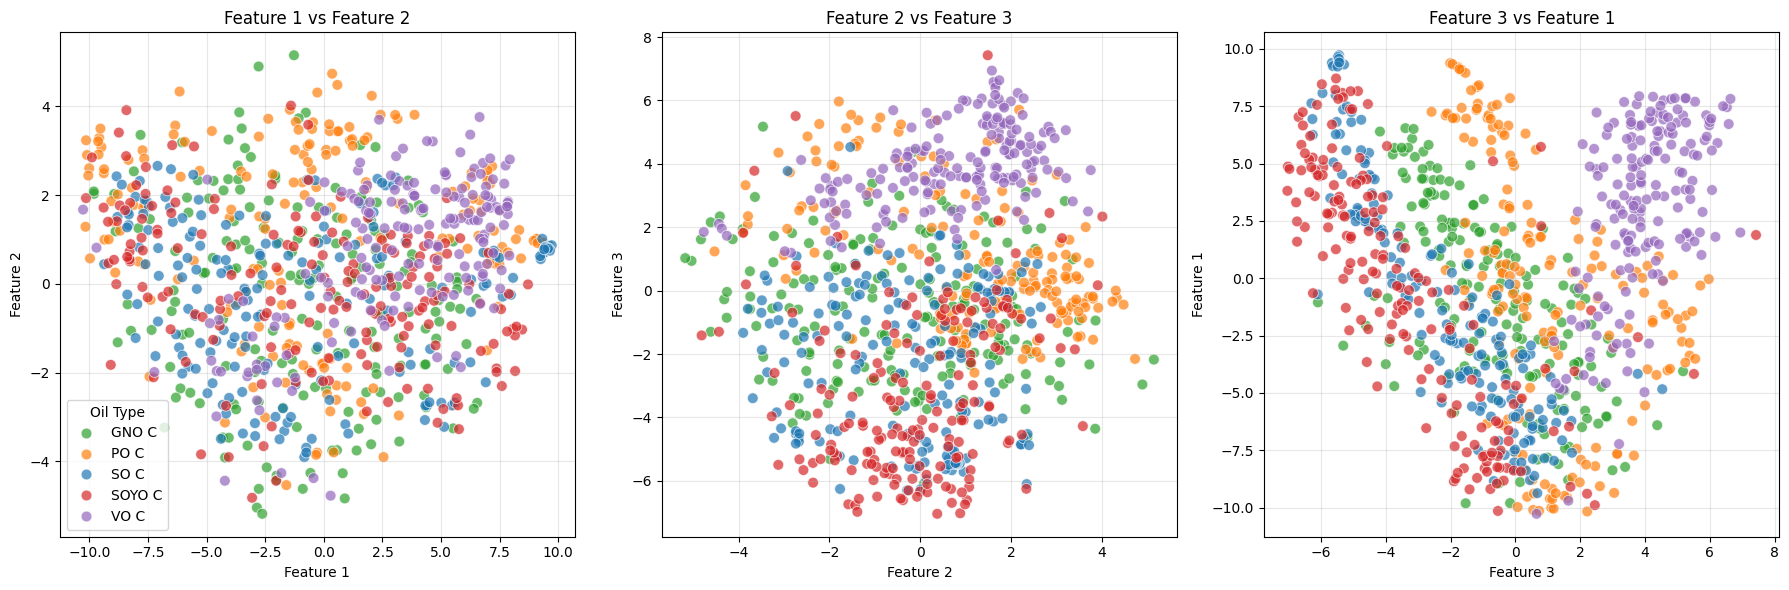

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Feature 1 vs Feature 2
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 1",
    y="Feature 2",
    hue="Oil Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[0]
)

axes[0].set_title("Feature 1 vs Feature 2")
axes[0].grid(alpha=0.3)

# Feature 2 vs Feature 3
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 2",
    y="Feature 3",
    hue="Oil Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[1]
)

axes[1].set_title("Feature 2 vs Feature 3")
axes[1].grid(alpha=0.3)

# Feature 3 vs Feature 1
sns.scatterplot(
    data=tsne_3d_data,
    x="Feature 3",
    y="Feature 1",
    hue="Oil Type",
    palette=palette,
    alpha=0.7,
    s=60,
    ax=axes[2]
)

axes[2].set_title("Feature 3 vs Feature 1")
axes[2].grid(alpha=0.3)

# Keep only one legend
axes[1].legend_.remove()
axes[2].legend_.remove()

plt.tight_layout()

plt.savefig(r"Images\K-Means Clusters\tsne_3d_pairwise_projections_chips.png",dpi=300,bbox_inches="tight")
plt.show()

In [24]:
palette = {
    "SO C": "blue",
    "PO C": "orange",
    "GNO C": "green",
    "SOYO C": "red",
    "VO C": "purple"
}

# Add TRUE labels to 3D t-SNE
tsne_3d_data["True_Label"] = y.values

fig = px.scatter_3d(
    tsne_3d_data,
    x="Feature 1",
    y="Feature 2",
    z="Feature 3",
    color="True_Label",
    color_discrete_map=palette,
    title="t-SNE 3D (True Labels)"
)
fig.write_image(r"Images\K-Means Clusters\tsne_3d_chips_plot.jpg")
fig.show()

In [25]:
k_means_df = subset_scaled_df.copy()

### Elbow (WCSS) across k=2..20: Fit K‑means and record inertia to eyeball elbow.

In [26]:
clusters = range(2, 11)
WCSS = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=RS)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)

    wcss = model.inertia_


    WCSS.append(wcss)

    print("Number of Clusters:", k, "\twcss:", wcss)

Number of Clusters: 2 	wcss: 1355223.2647472552
Number of Clusters: 3 	wcss: 1255060.0997165395
Number of Clusters: 4 	wcss: 1199992.801090201
Number of Clusters: 5 	wcss: 1155489.45359496
Number of Clusters: 6 	wcss: 1134303.8699853641


Number of Clusters: 7 	wcss: 1116806.2909579375
Number of Clusters: 8 	wcss: 1105317.4975468435
Number of Clusters: 9 	wcss: 1097759.4043528703
Number of Clusters: 10 	wcss: 1079099.9776593682


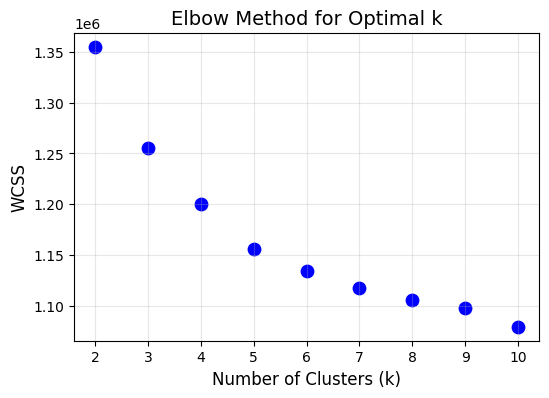

In [27]:
plt.figure(figsize=(6,4))

plt.scatter(
    clusters,
    WCSS,
    s=80,           # marker size
    color='blue',
    marker='o'
)

plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("WCSS", fontsize=12)
plt.title("Elbow Method for Optimal k", fontsize=14)

plt.xticks(clusters)
plt.grid(alpha=0.3)

plt.savefig(r"Images\K-Means Clusters\elbow_plot_chips.jpg",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [28]:
K_Means = []
WCSS_Chips = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RS)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)

    wcss = model.inertia_

    K_Means.append(k)
    WCSS_Chips.append(wcss)

print("K-Means:", K_Means)
print("WCSS_Chips:", WCSS_Chips)

K-Means: [2, 3, 4, 5, 6, 7, 8, 9, 10]
WCSS_Chips: [1355223.2647472552, 1255060.0997165395, 1199992.801090201, 1155489.45359496, 1134303.8699853641, 1116806.2909579375, 1105317.4975468435, 1097759.4043528703, 1079099.9776593682]


### Compute silhouette scores for k=2..9 and plot them to complement elbow.

In [29]:
sil_score = []
cluster_list = range(2, 10)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=RS)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

For n_clusters = 2, the silhouette score is 0.20630888811831213)
For n_clusters = 3, the silhouette score is 0.15160265710718807)
For n_clusters = 4, the silhouette score is 0.11041064216952307)
For n_clusters = 5, the silhouette score is 0.06136362459289904)


For n_clusters = 6, the silhouette score is 0.05596200011605452)


For n_clusters = 7, the silhouette score is 0.050724992082535995)
For n_clusters = 8, the silhouette score is 0.038900880231104)
For n_clusters = 9, the silhouette score is 0.03373700282854046)


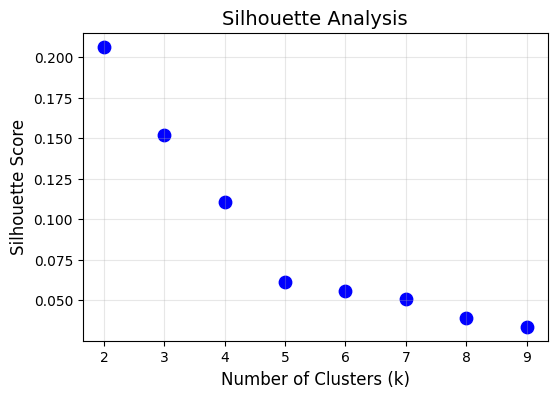

In [30]:
plt.figure(figsize=(6,4))

plt.scatter(
    cluster_list,
    sil_score,
    s=80,
    color='blue',
    marker='o'
)

plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Analysis", fontsize=14)

plt.xticks(cluster_list)
plt.grid(alpha=0.3)

plt.savefig(r"Images\K-Means Clusters\silhouette_chips_plot.jpg",dpi=300, bbox_inches='tight')

plt.show()

In [31]:
n_clusters = list(range(2, 10))
sil_chips = []

for n_cluster in n_clusters:
    clusterer = KMeans(n_clusters=n_cluster, random_state=RS)
    preds = clusterer.fit_predict(subset_scaled_df)
    score = silhouette_score(k_means_df, preds)
    sil_chips.append(score)

    print("For n_clusters = {}, the silhouette score is {}".format(n_cluster, score))

print("n_clusters:", n_clusters)
print("sil_chips:", sil_chips)

For n_clusters = 2, the silhouette score is 0.20630888811831213
For n_clusters = 3, the silhouette score is 0.15160265710718807
For n_clusters = 4, the silhouette score is 0.11041064216952307
For n_clusters = 5, the silhouette score is 0.06136362459289904
For n_clusters = 6, the silhouette score is 0.05596200011605452


For n_clusters = 7, the silhouette score is 0.050724992082535995
For n_clusters = 8, the silhouette score is 0.038900880231104
For n_clusters = 9, the silhouette score is 0.03373700282854046
n_clusters: [2, 3, 4, 5, 6, 7, 8, 9]
sil_chips: [0.20630888811831213, 0.15160265710718807, 0.11041064216952307, 0.06136362459289904, 0.05596200011605452, 0.050724992082535995, 0.038900880231104, 0.03373700282854046]


In [32]:
# Ensure column names are strings (required by sklearn sometimes)
k_means_df.columns = k_means_df.columns.astype(str)
# -------- K-MEANS MODEL --------
kmeans = KMeans(n_clusters=5, random_state=RS)
kmeans.fit(k_means_df)

# -------- CREATE COPIES --------
df1 = df.copy()   # original (unscaled)

In [33]:
# -------- ASSIGN CLUSTERS --------
k_means_df["K_means_segments"] = kmeans.labels_      # scaled data
df1["K_means_segments"] = kmeans.labels_             # original data
tsne_2d_data["K_means_segments"] = kmeans.labels_    # t-SNE 2D
tsne_3d_data["K_means_segments"] = kmeans.labels_    # t-SNE 3D

In [34]:
#Add cluster number 
tsne_2d_data["Cluster"] = kmeans.labels_
#Add true oil labels
tsne_2d_data["True_Label"] = y.values
print(tsne_2d_data["True_Label"].value_counts())

True_Label
GNO C     180
PO C      180
SO C      180
SOYO C    180
VO C      180
Name: count, dtype: int64


In [35]:
# Map cluster number -> oil name
cluster_map = pd.crosstab(y, kmeans.labels_).idxmax()

# Convert to dictionary
mapping = cluster_map.to_dict()

# Create cluster labels
tsne_2d_data["Cluster_Label"] = pd.Series(kmeans.labels_).map(mapping)

print(tsne_2d_data["Cluster_Label"].value_counts())

Cluster_Label
GNO C     343
SO C      251
SOYO C    161
VO C      145
Name: count, dtype: int64


In [36]:
# 1. Cross-tabulation (MOST IMPORTANT)
cluster_vs_label = pd.crosstab(y, kmeans.labels_, margins=True)
print("\n=== Cluster vs True Label Comparison ===")
print(cluster_vs_label)
# 2. Dominant cluster per oil type (optional but very important)
dominant_cluster = cluster_vs_label.drop("All", axis=1).idxmax(axis=1)
print("\n=== Dominant Cluster for Each Oil Type ===")
print(dominant_cluster)
# 3. (OPTIONAL) Add TRUE labels to t-SNE for visual validation
tsne_2d_data["True_Label"] = y.values


=== Cluster vs True Label Comparison ===
col_0       0   1    2    3    4  All
Oil Type                             
GNO C      96   0   50    0   34  180
PO C       90   7    7   33   43  180
SO C       49  21   38    0   72  180
SOYO C     46  17   66    0   51  180
VO C       62   0    0  112    6  180
All       343  45  161  145  206  900

=== Dominant Cluster for Each Oil Type ===
Oil Type
GNO C     0
PO C      0
SO C      4
SOYO C    2
VO C      3
All       0
dtype: object


In [37]:
print(tsne_2d_data.columns)

Index(['Feature 1', 'Feature 2', 'Oil Type', 'K_means_segments', 'Cluster',
       'True_Label', 'Cluster_Label'],
      dtype='object')


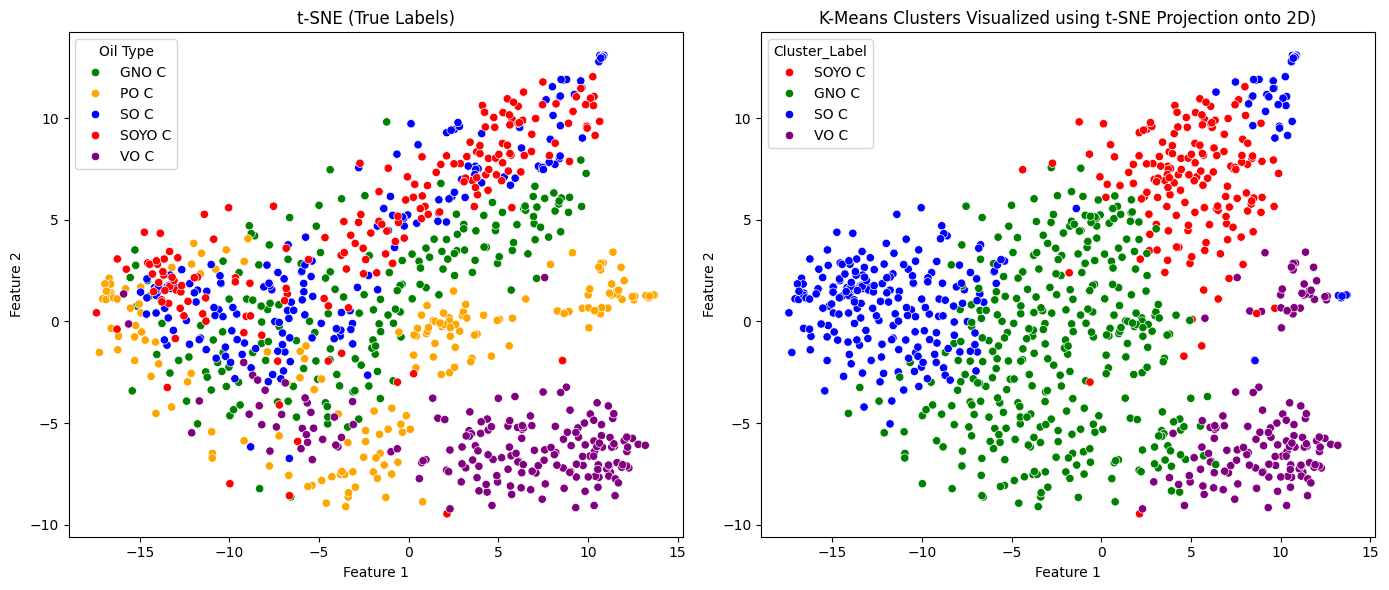

In [38]:
# Plot TRUE label vs CLUSTER comparison side-by-side
plt.figure(figsize=(14,6))
# TRUE LABELS
plt.subplot(1,2,1)
sns.scatterplot(
    data=tsne_2d_data,
    x="Feature 1",
    y="Feature 2",
    #hue="True_Label",
    hue="Oil Type",
    palette=palette
    #palette="tab10"
)
plt.title("t-SNE (True Labels)")
# CLUSTERS
plt.subplot(1,2,2)
sns.scatterplot(
    data=tsne_2d_data,
    x="Feature 1",
    y="Feature 2",
    #hue="K_means_segments",
    hue="Cluster_Label",
    #hue = "Cluster",
    #palette="tab10"
    palette=palette
)
plt.title("K-Means Clusters Visualized using t-SNE Projection onto 2D)")
plt.tight_layout()
plt.savefig(r"Images\K-Means Clusters\kmeans_tsne_clusters_chips.jpg", dpi = 300, bbox_inches = 'tight')
plt.show()

### Attach cluster labels back to data and visualize on t‑SNE and append `K_means_segments` and produce 2D/3D plots with color by cluster.

In [39]:
# Create Cluster Profile: Mean spectra per cluster
km_cluster_profile = df1.groupby("K_means_segments").mean(numeric_only = True)
km_cluster_profile

500.9077  501.8718  502.8362  503.8003  504.7646  505.7288  \
K_means_segments                                                               
0                -0.017708 -0.051749 -0.068137 -0.073658 -0.071547 -0.061318   
1                 1.107551  1.253042  1.290819  1.368333  1.486635  1.588939   
2                 0.411548  0.423385  0.384629  0.356036  0.341366  0.331908   
3                 0.190673  0.317138  0.363862  0.374963  0.364185  0.328069   
4                -0.668315 -0.741684 -0.725247 -0.718455 -0.728760 -0.735327   

                  506.6931  507.6572  508.6216  509.5857    510.55  511.5142  \
K_means_segments                                                               
0                -0.045758 -0.024918 -0.003515  0.016738  0.037015  0.055692   
1                 1.632019  1.622902  1.575408  1.512009  1.445179  1.386042   
2                 0.339143  0.363793  0.391773  0.410160  0.410235  0.400224   
3                 0.280732  0.225730  0.176925  0.138675  0.101408  0.058858   
4                -0.742981 -0.756240 -0.769017 -0.776336 -0.769326 -0.749732   

                  512.4785  513.4426   514.407  515.3711  516.3354  517.2996  \
K_means_segments                                                               
0                 0.069856  0.075759  0.072388  0.060876  0.042532  0.019167   
1                 1.336141  1.283932  1.241098  1.191367  1.133110  1.078318   
2                 0.383516  0.360713  0.341752  0.337580  0.350674  0.364635   
3                 0.009494 -0.037222 -0.073382 -0.090854 -0.075660 -0.011952   
4                -0.714610 -0.662330 -0.607089 -0.561498 -0.539156 -0.544038   

                  518.2639   519.228  520.1924  521.1565  522.1208   523.085  \
K_means_segments                                                               
0                -0.007573 -0.036726 -0.065119 -0.085985 -0.095268 -0.091792   
1                 1.037199  1.029192  1.046677  1.056671  1.059307  1.027957   
2                 0.354238  0.312649  0.251250  0.202752  0.187248  0.207957   
3                 0.100429  0.236556  0.357526  0.423055  0.430877  0.389756   
4                -0.561509 -0.574533 -0.568238 -0.543899 -0.522409 -0.508588   

                  524.0493  525.0134  525.9778  526.9419  527.9063  528.8704  \
K_means_segments                                                               
0                -0.078719 -0.058952 -0.036247 -0.015628 -0.000158  0.009665   
1                 0.958267  0.862918  0.767230  0.712666  0.711843  0.761708   
2                 0.241531  0.261317  0.249645  0.210084  0.152092  0.089030   
3                 0.329855  0.288216  0.275917  0.293536  0.322111  0.337708   
4                -0.499208 -0.497446 -0.496571 -0.500465 -0.500833 -0.489774   

                  529.8347  530.7988  531.7632  532.7273  533.6917  534.6558  \
K_means_segments                                                               
0                 0.019340  0.036227  0.060972  0.090997  0.115148  0.129318   
1                 0.840171  0.885313  0.839717  0.683860  0.453749  0.215426   
2                 0.036404  0.008361  0.003323  0.011138  0.008055 -0.013613   
3                 0.324287  0.269063  0.188212  0.104165  0.055216  0.046826   
4                -0.472447 -0.449637 -0.420030 -0.382927 -0.336008 -0.284701   

                  535.6201  536.5842  537.5486  538.5127  539.4771  540.4412  \
K_means_segments                                                               
0                 0.129621  0.117039  0.098124  0.075665  0.053761  0.031985   
1                 0.015676 -0.129988 -0.221405 -0.230566 -0.125888  0.062592   
2                -0.052078 -0.090632 -0.112624 -0.110159 -0.089971 -0.065239   
3                 0.052862  0.065843  0.087862  0.118016  0.153504  0.187372   
4                -0.215757 -0.141993 -0.088840 -0.072594 -0.099746 -0.147830   

                  541.4055  542.3696   543.334  544.2981  545.2625  546.2266  \
K_means_seg

In [40]:
# Add count of points in each cluster: 
km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("K_means_segments").size().values)

# Display profile
km_cluster_profile

500.9077  501.8718  502.8362  503.8003  504.7646  505.7288  \
K_means_segments                                                               
0                -0.017708 -0.051749 -0.068137 -0.073658 -0.071547 -0.061318   
1                 1.107551  1.253042  1.290819  1.368333  1.486635  1.588939   
2                 0.411548  0.423385  0.384629  0.356036  0.341366  0.331908   
3                 0.190673  0.317138  0.363862  0.374963  0.364185  0.328069   
4                -0.668315 -0.741684 -0.725247 -0.718455 -0.728760 -0.735327   

                  506.6931  507.6572  508.6216  509.5857    510.55  511.5142  \
K_means_segments                                                               
0                -0.045758 -0.024918 -0.003515  0.016738  0.037015  0.055692   
1                 1.632019  1.622902  1.575408  1.512009  1.445179  1.386042   
2                 0.339143  0.363793  0.391773  0.410160  0.410235  0.400224   
3                 0.280732  0.225730  0.176925  0.138675  0.101408  0.058858   
4                -0.742981 -0.756240 -0.769017 -0.776336 -0.769326 -0.749732   

                  512.4785  513.4426   514.407  515.3711  516.3354  517.2996  \
K_means_segments                                                               
0                 0.069856  0.075759  0.072388  0.060876  0.042532  0.019167   
1                 1.336141  1.283932  1.241098  1.191367  1.133110  1.078318   
2                 0.383516  0.360713  0.341752  0.337580  0.350674  0.364635   
3                 0.009494 -0.037222 -0.073382 -0.090854 -0.075660 -0.011952   
4                -0.714610 -0.662330 -0.607089 -0.561498 -0.539156 -0.544038   

                  518.2639   519.228  520.1924  521.1565  522.1208   523.085  \
K_means_segments                                                               
0                -0.007573 -0.036726 -0.065119 -0.085985 -0.095268 -0.091792   
1                 1.037199  1.029192  1.046677  1.056671  1.059307  1.027957   
2                 0.354238  0.312649  0.251250  0.202752  0.187248  0.207957   
3                 0.100429  0.236556  0.357526  0.423055  0.430877  0.389756   
4                -0.561509 -0.574533 -0.568238 -0.543899 -0.522409 -0.508588   

                  524.0493  525.0134  525.9778  526.9419  527.9063  528.8704  \
K_means_segments                                                               
0                -0.078719 -0.058952 -0.036247 -0.015628 -0.000158  0.009665   
1                 0.958267  0.862918  0.767230  0.712666  0.711843  0.761708   
2                 0.241531  0.261317  0.249645  0.210084  0.152092  0.089030   
3                 0.329855  0.288216  0.275917  0.293536  0.322111  0.337708   
4                -0.499208 -0.497446 -0.496571 -0.500465 -0.500833 -0.489774   

                  529.8347  530.7988  531.7632  532.7273  533.6917  534.6558  \
K_means_segments                                                               
0                 0.019340  0.036227  0.060972  0.090997  0.115148  0.129318   
1                 0.840171  0.885313  0.839717  0.683860  0.453749  0.215426   
2                 0.036404  0.008361  0.003323  0.011138  0.008055 -0.013613   
3                 0.324287  0.269063  0.188212  0.104165  0.055216  0.046826   
4                -0.472447 -0.449637 -0.420030 -0.382927 -0.336008 -0.284701   

                  535.6201  536.5842  537.5486  538.5127  539.4771  540.4412  \
K_means_segments                                                               
0                 0.129621  0.117039  0.098124  0.075665  0.053761  0.031985   
1                 0.015676 -0.129988 -0.221405 -0.230566 -0.125888  0.062592   
2                -0.052078 -0.090632 -0.112624 -0.110159 -0.089971 -0.065239   
3                 0.052862  0.065843  0.087862  0.118016  0.153504  0.187372   
4                -0.215757 -0.141993 -0.088840 -0.072594 -0.099746 -0.147830   

                  541.4055  542.3696   543.334  544.2981  545.2625  546.2266  \
K_means_seg

In [41]:
km_cluster_profile.index = km_cluster_profile.index.map(mapping)
km_cluster_profile

500.9077  501.8718  502.8362  503.8003  504.7646  505.7288  \
K_means_segments                                                               
GNO C            -0.017708 -0.051749 -0.068137 -0.073658 -0.071547 -0.061318   
SO C              1.107551  1.253042  1.290819  1.368333  1.486635  1.588939   
SOYO C            0.411548  0.423385  0.384629  0.356036  0.341366  0.331908   
VO C              0.190673  0.317138  0.363862  0.374963  0.364185  0.328069   
SO C             -0.668315 -0.741684 -0.725247 -0.718455 -0.728760 -0.735327   

                  506.6931  507.6572  508.6216  509.5857    510.55  511.5142  \
K_means_segments                                                               
GNO C            -0.045758 -0.024918 -0.003515  0.016738  0.037015  0.055692   
SO C              1.632019  1.622902  1.575408  1.512009  1.445179  1.386042   
SOYO C            0.339143  0.363793  0.391773  0.410160  0.410235  0.400224   
VO C              0.280732  0.225730  0.176925  0.138675  0.101408  0.058858   
SO C             -0.742981 -0.756240 -0.769017 -0.776336 -0.769326 -0.749732   

                  512.4785  513.4426   514.407  515.3711  516.3354  517.2996  \
K_means_segments                                                               
GNO C             0.069856  0.075759  0.072388  0.060876  0.042532  0.019167   
SO C              1.336141  1.283932  1.241098  1.191367  1.133110  1.078318   
SOYO C            0.383516  0.360713  0.341752  0.337580  0.350674  0.364635   
VO C              0.009494 -0.037222 -0.073382 -0.090854 -0.075660 -0.011952   
SO C             -0.714610 -0.662330 -0.607089 -0.561498 -0.539156 -0.544038   

                  518.2639   519.228  520.1924  521.1565  522.1208   523.085  \
K_means_segments                                                               
GNO C            -0.007573 -0.036726 -0.065119 -0.085985 -0.095268 -0.091792   
SO C              1.037199  1.029192  1.046677  1.056671  1.059307  1.027957   
SOYO C            0.354238  0.312649  0.251250  0.202752  0.187248  0.207957   
VO C              0.100429  0.236556  0.357526  0.423055  0.430877  0.389756   
SO C             -0.561509 -0.574533 -0.568238 -0.543899 -0.522409 -0.508588   

                  524.0493  525.0134  525.9778  526.9419  527.9063  528.8704  \
K_means_segments                                                               
GNO C            -0.078719 -0.058952 -0.036247 -0.015628 -0.000158  0.009665   
SO C              0.958267  0.862918  0.767230  0.712666  0.711843  0.761708   
SOYO C            0.241531  0.261317  0.249645  0.210084  0.152092  0.089030   
VO C              0.329855  0.288216  0.275917  0.293536  0.322111  0.337708   
SO C             -0.499208 -0.497446 -0.496571 -0.500465 -0.500833 -0.489774   

                  529.8347  530.7988  531.7632  532.7273  533.6917  534.6558  \
K_means_segments                                                               
GNO C             0.019340  0.036227  0.060972  0.090997  0.115148  0.129318   
SO C              0.840171  0.885313  0.839717  0.683860  0.453749  0.215426   
SOYO C            0.036404  0.008361  0.003323  0.011138  0.008055 -0.013613   
VO C              0.324287  0.269063  0.188212  0.104165  0.055216  0.046826   
SO C             -0.472447 -0.449637 -0.420030 -0.382927 -0.336008 -0.284701   

                  535.6201  536.5842  537.5486  538.5127  539.4771  540.4412  \
K_means_segments                                                               
GNO C             0.129621  0.117039  0.098124  0.075665  0.053761  0.031985   
SO C              0.015676 -0.129988 -0.221405 -0.230566 -0.125888  0.062592   
SOYO C           -0.052078 -0.090632 -0.112624 -0.110159 -0.089971 -0.065239   
VO C              0.052862  0.065843  0.087862  0.118016  0.153504  0.187372   
SO C             -0.215757 -0.141993 -0.088840 -0.072594 -0.099746 -0.147830   

                  541.4055  542.3696   543.334  544.2981  545.2625  546.2266  \
K_means_seg

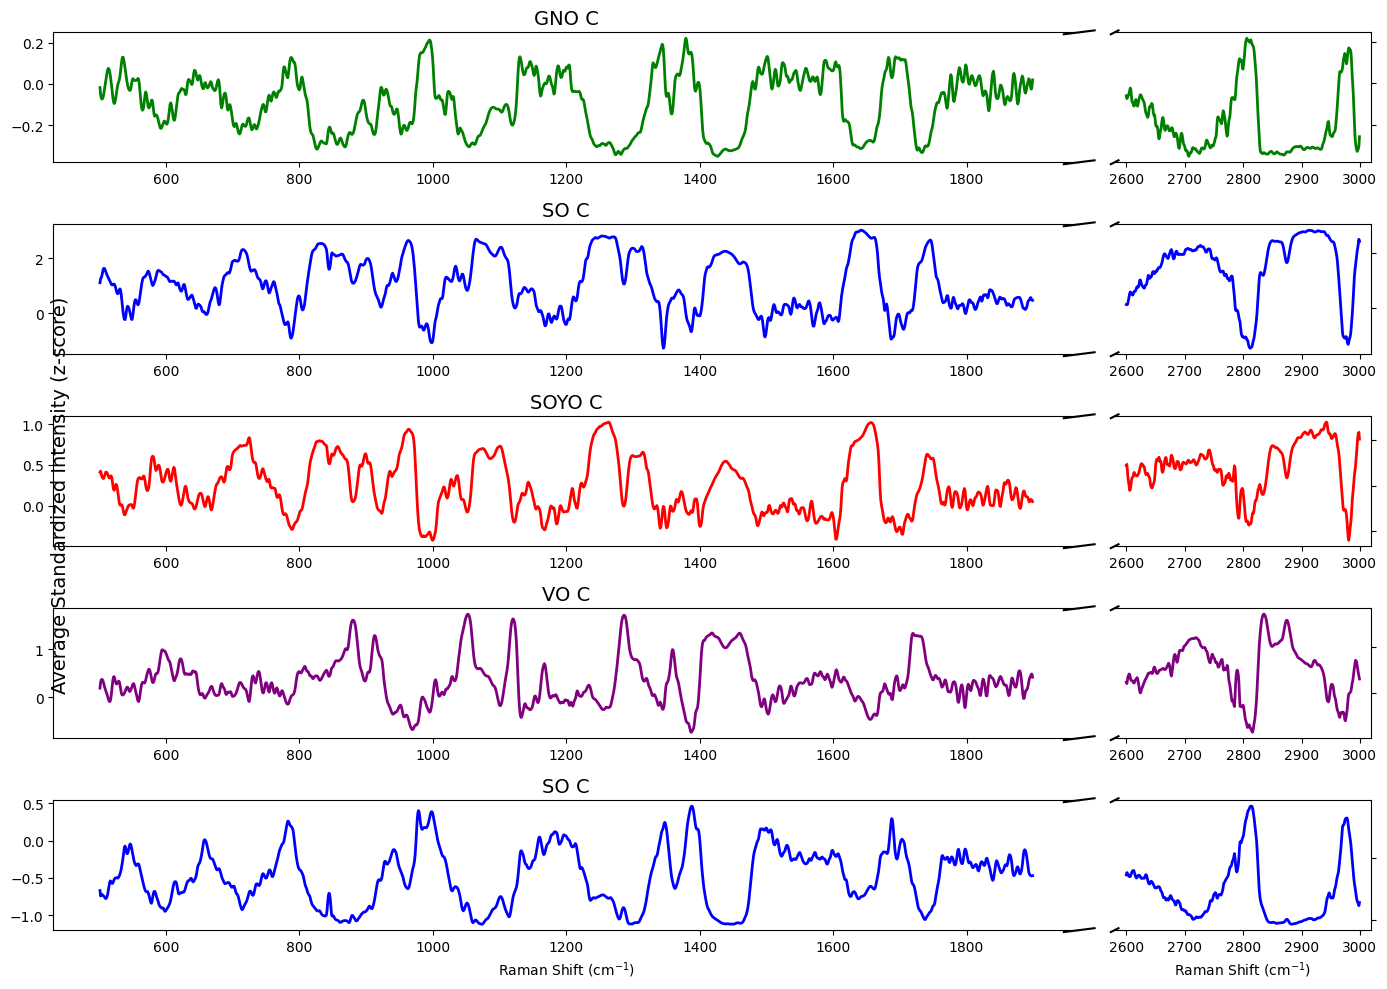

In [42]:
# -------------------------
# Spectral data only
# -------------------------
spectral_data = km_cluster_profile.copy()

# Remove count column if present
if "count_in_each_segment" in spectral_data.columns:
    spectral_data = spectral_data.drop(columns=["count_in_each_segment"])

# Raman shifts
x = spectral_data.columns.astype(float)

# Region break
mask1 = x <= 1900
mask2 = x >= 2600

# Use the SAME colors as your t-SNE plots
cluster_colors = {
    "GNO C": "green",
    "VO C": "purple",
    "PO C": "orange",
    "SO C": "blue",
    "SOYO C": "red"
}

# -------------------------
# Figure
# -------------------------
fig, axes = plt.subplots(
    len(spectral_data.index),
    2,
    figsize=(14, 10),
    gridspec_kw={"width_ratios":[4,1]},
    sharey=False
)

for row in range(len(spectral_data)):
    cluster = spectral_data.index[row]
    y = spectral_data.iloc[row].to_numpy()
    color = cluster_colors[cluster]

    # Left region
    axes[row,0].plot(
        x[mask1],
        y[mask1],
        color=cluster_colors[cluster],
        linewidth=2
    )

    # Right region
    axes[row,1].plot(
        x[mask2],
        y[mask2],
        color=cluster_colors[cluster],
        linewidth=2
    )

    axes[row,0].set_title(cluster, fontsize=14)

    # Hide touching spines
    axes[row,0].spines["right"].set_visible(False)
    axes[row,1].spines["left"].set_visible(False)

    axes[row,1].yaxis.tick_right()
    axes[row,1].tick_params(labelright=False)

    # Break marks
    d = .015

    kwargs = dict(
        transform=axes[row,0].transAxes,
        color='k',
        clip_on=False
    )

    axes[row,0].plot((1-d,1+d),(-d,+d), **kwargs)
    axes[row,0].plot((1-d,1+d),(1-d,1+d), **kwargs)

    kwargs.update(transform=axes[row,1].transAxes)

    axes[row,1].plot((-d,+d),(-d,+d), **kwargs)
    axes[row,1].plot((-d,+d),(1-d,1+d), **kwargs)

# Labels
axes[-1,0].set_xlabel("Raman Shift (cm$^{-1}$)")
axes[-1,1].set_xlabel("Raman Shift (cm$^{-1}$)")

fig.text(
    0.04,
    0.5,
    "Average Standardized Intensity (z-score)",
    va='center',
    rotation='vertical',
    fontsize=14
)

plt.tight_layout()

plt.savefig(r"Images\K-Means Clusters\cluster_profiles_broken_axis_chips.jpg",dpi=300,bbox_inches="tight")

plt.show()